# NHANES 2017-2018 EDA for Bayesian Network

This notebook explores the NHANES datasets (XPT) to prepare a clean, merged dataset suitable for Bayesian Network structure learning.

- Data source: `dataset/*.xpt`
- Key ID: `SEQN`
- Outputs:
  - `outputs/merged.csv`: merged, row-wise dataset on `SEQN`
  - `outputs/eda/` figures and profiling assets

Sections:
1. Load libraries and helpers
2. Discover and load XPT files
3. Inspect schemas and value distributions
4. Merge datasets on `SEQN`
5. Dataset overview and missingness
6. Univariate summaries
7. Bivariate associations
8. Save cleaned/merged data


In [1]:
# 1) Imports and configuration
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

PROJECT_ROOT = Path("/Users/derrick.quach/Desktop/health-risk-bayesian-network")
DATA_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "eda"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Helper: read XPT file with pandas
# Pandas reads SAS xport via read_sas with format="xport"
def read_xpt(path: Path) -> pd.DataFrame:
    return pd.read_sas(str(path), format="xport")

# Helper: concise info
def df_info(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print(df.head(3))


In [2]:
# 2) Discover and load XPT files
xpt_paths = sorted(DATA_DIR.glob("*.xpt"))
assert len(xpt_paths) > 0, "No XPT files found in dataset/"

xpt_dfs = {}
for path in xpt_paths:
    key = path.stem  # e.g., P_DEMO
    try:
        df = read_xpt(path)
        # Ensure SEQN exists if present
        if "SEQN" in df.columns:
            df["SEQN"] = df["SEQN"].astype("int64")
        xpt_dfs[key] = df
    except Exception as e:
        print(f"Failed to read {path.name}: {e}")

# Preview schemas
for key, df in xpt_dfs.items():
    df_info(df, key)



=== P_ALQ ===
shape: (8965, 10)
columns: ['SEQN', 'ALQ111', 'ALQ121', 'ALQ130', 'ALQ142', 'ALQ270', 'ALQ280', 'ALQ290', 'ALQ151', 'ALQ170']
     SEQN  ALQ111        ALQ121  ALQ130        ALQ142  ALQ270  ALQ280  ALQ290  \
0  109266     1.0  1.000000e+01     1.0  5.397605e-79     NaN     NaN     NaN   
1  109271     1.0  5.397605e-79     NaN           NaN     NaN     NaN     NaN   
2  109273     1.0  5.397605e-79     NaN           NaN     NaN     NaN     NaN   

   ALQ151        ALQ170  
0     2.0  5.397605e-79  
1     1.0           NaN  
2     2.0           NaN  

=== P_BMX ===
shape: (14300, 22)
columns: ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']
     SEQN  BMDSTATS  BMXWT  BMIWT  BMXRECUM  BMIRECUM  BMXHEAD  BMIHEAD  \
0  109263       4.0    NaN    NaN       NaN       NaN      NaN      NaN   
1  10

In [3]:
# 3) Merge datasets on SEQN
# Choose a conservative subset first; expand later as needed
keys = sorted(xpt_dfs.keys())
print("Datasets discovered:", keys)

# Start from DEMO (demographics) if present; else first dataset
demo_key = next((k for k in keys if "DEMO" in k.upper()), keys[0])
merged = xpt_dfs[demo_key].copy()

for k in keys:
    if k == demo_key:
        continue
    df = xpt_dfs[k]
    if "SEQN" in df.columns:
        # Inner join to keep only respondents present in both; change to outer if desired
        merged = merged.merge(df, on="SEQN", how="left", suffixes=("", f"_{k}"))

print("Merged shape:", merged.shape)
merged.head(3)


Datasets discovered: ['P_ALQ', 'P_BMX', 'P_BPQ', 'P_DEMO', 'P_DIQ', 'P_GHB', 'P_GLU', 'P_INS', 'P_PAQ', 'P_SMQ']
Merged shape: (15560, 135)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDYRUSZ,DMDEDUC2,DMDMARTZ,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,BPQ020,...,DIQ060U,DIQ070,DIQ230,DIQ240,DID250,DID260,DIQ260U,DIQ275,DIQ280,DIQ291,DIQ300S,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080,LBXGH,WTSAFPRP,LBXGLU,LBDGLUSI,WTSAFPRP_P_INS,LBXIN,LBDINSI,LBDINLC,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMAQUEX2
0,109263,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,7891.762435,8951.815567,3.0,156.0,4.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,11689.747264,12271.157043,1.0,155.0,0.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,42.2,NaN,NaN,NaN,NaN,NaN,154.7,NaN,17.6,2.0,36.3,NaN,33.8,NaN,22.7,NaN,63.8,NaN,85.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,27533.174559,97.0,5.38,27533.174559,6.05,36.3,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0
2,109265,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,16273.825939,16658.764203,1.0,157.0,3.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,12.0,NaN,91.6,NaN,NaN,NaN,89.3,NaN,15.0,2.0,NaN,NaN,18.6,NaN,14.8,NaN,41.2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 4) Overview: shape, dtypes, basic stats
print("Rows, Columns:", merged.shape)
print("\nDtypes summary:\n", merged.dtypes.value_counts())

# display(merged.describe(include=[np.number]).T.head(20))
# display(merged.describe(include=["object", "category"]).T.head(20))


Rows, Columns: (15560, 135)

Dtypes summary:
 float64    134
int64        1
Name: count, dtype: int64


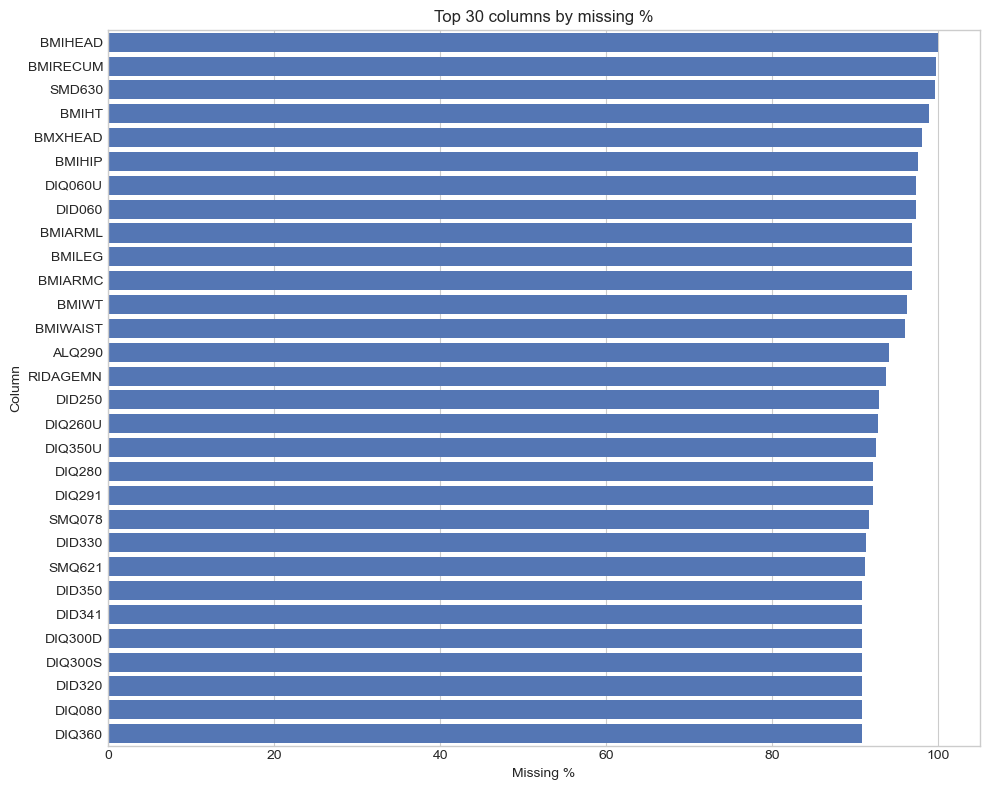

In [6]:
# 5) Missingness analysis
missing_counts = merged.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(merged) * 100).round(2)
miss_df = pd.DataFrame({"missing": missing_counts, "missing_pct": missing_pct})
miss_df.head(20)

# Visualize top missing columns
TOP_N = 30
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_pct.head(TOP_N), y=missing_pct.head(TOP_N).index, color="#4472C4")
plt.title(f"Top {TOP_N} columns by missing %")
plt.xlabel("Missing %")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_top_cols.png", dpi=150)
plt.show()


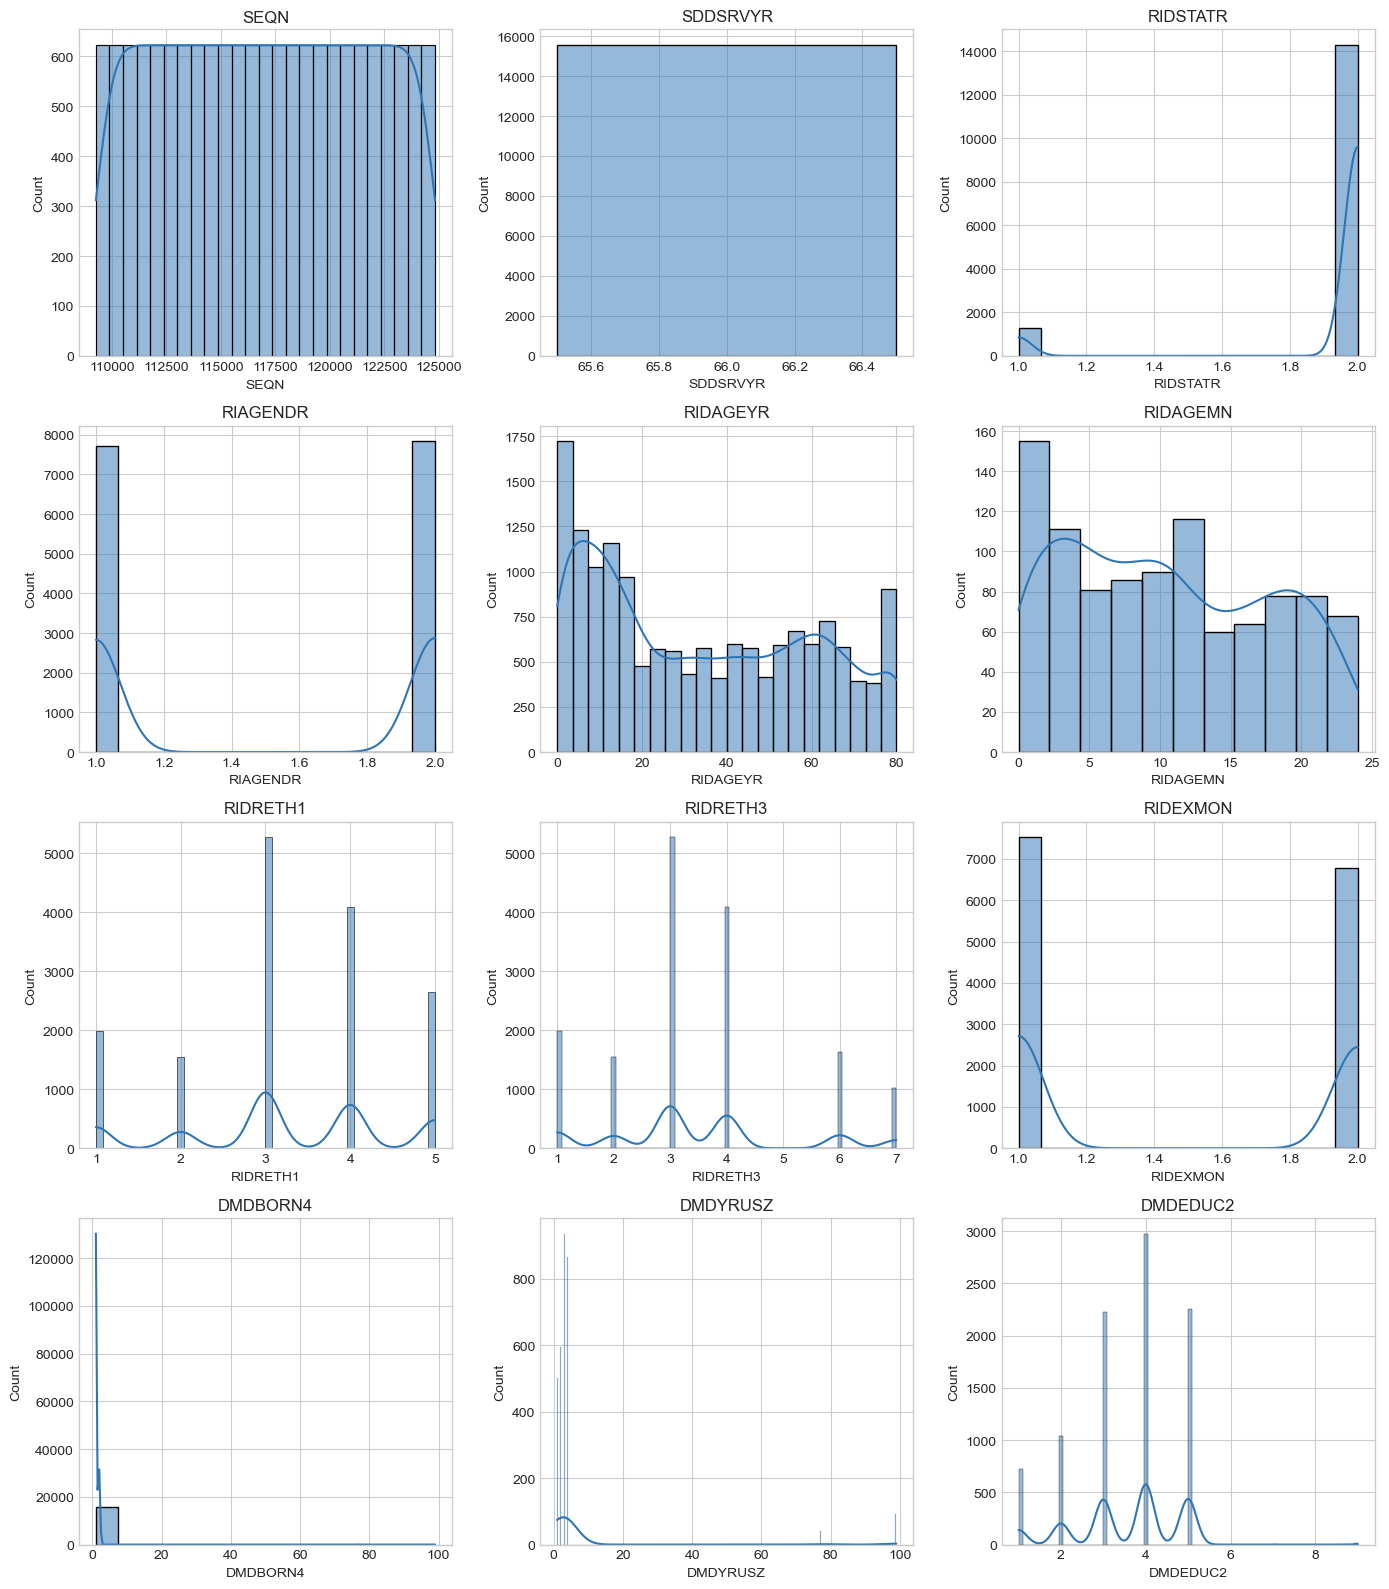

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1400x0 with 0 Axes>

In [7]:
# 6) Univariate summaries
# Numeric histograms
num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
SAMPLE_NUM = min(12, len(num_cols))

fig, axes = plt.subplots(nrows=int(np.ceil(SAMPLE_NUM/3)), ncols=3, figsize=(14, 4*int(np.ceil(SAMPLE_NUM/3))))
axes = axes.flatten()
for i, col in enumerate(num_cols[:SAMPLE_NUM]):
    sns.histplot(merged[col].dropna(), kde=True, ax=axes[i], color="#2E75B6")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / "univariate_numeric_sample.png", dpi=150)
plt.show()

# Categorical bar plots (limited to low cardinality)
cat_cols = [c for c in merged.columns if merged[c].dtype == 'object' or str(merged[c].dtype).startswith('category')]
low_card = [c for c in cat_cols if merged[c].nunique(dropna=True) <= 15][:12]

fig, axes = plt.subplots(nrows=int(np.ceil(len(low_card)/3)), ncols=3, figsize=(14, 4*int(np.ceil(len(low_card)/3))))
axes = axes.flatten()
for i, col in enumerate(low_card):
    merged[col].value_counts(dropna=False).head(15).plot(kind='bar', ax=axes[i], color="#70AD47")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / "univariate_categorical_sample.png", dpi=150)
plt.show()


In [ ]:

num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
SAMPLE_NUM = min(25, len(num_cols))
subset = merged[num_cols[:SAMPLE_NUM]].copy()

corr = subset.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, square=True)
plt.title("Correlation heatmap (numeric sample)")
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_heatmap_sample.png", dpi=150)
plt.show()

# Simple associations for categorical targets vs numeric predictors
# Choose a few known targets if present
target_candidates = [
    "BPXSY1",  # Systolic BP
    "BPXDI1",  # Diastolic BP
    "LBXGLU",  # Glucose
    "LBXGH",   # Hemoglobin A1c or similar depending on file
]
existing_targets = [t for t in target_candidates if t in merged.columns]

for t in existing_targets:
    top_corr = merged[num_cols].corrwith(merged[t], numeric_only=True).abs().sort_values(ascending=False).head(15)
    print(f"\nTop numeric correlations with {t}:")
    print(top_corr)



In [ ]:
# 8) Save merged dataset
merged_out = OUTPUT_DIR / "merged.csv"
merged.to_csv(merged_out, index=False)
print("Saved:", merged_out)
